In [2]:
import os
import urllib.parse
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the hidden variables from the .env file
load_dotenv()


# 2. Build your connection engine
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)



In [3]:
from pathlib import Path

# Step up to the project root and navigate into your target folder
sql_path = Path.cwd().parent / "queries" / "extract_movie_features.sql"

with open(sql_path, "r", encoding="utf-8") as file:
    query = file.read()

# 2. Execute query against database connection
df_raw = pd.read_sql(query, con=engine)

# 3. Create a clean working copy for Pandas transformations
df = df_raw.copy()

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns successfully!")
display(df.head())

Loaded 8040 rows and 29 columns successfully!


,movie_id,imdb_id,title,original_title,status,original_language,adult,video,release_date,release_year,...,vote_count,collection_name,is_part_of_franchise,primary_genre,primary_production_company,primary_country,director_name,cast,overview,tagline
0,5,tt0113101,Four Rooms,Four Rooms,Released,en,False,False,1995-12-09,1995.0,...,2896,NaN,0,Comedy,Miramax,United States,"Alexandre Rockwell, Allison Anders, Quentin Ta...","Tim Roth, Jennifer Beals, David Proval",It's Ted the Bellhop's first night on the job....,Twelve outrageous guests. Four scandalous requ...
1,6,tt0107286,Judgment Night,Judgment Night,Released,en,False,False,1993-10-15,1993.0,...,386,NaN,0,Drama,Universal Pictures,United States,Stephen Hopkins,"Emilio Estevez, Cuba Gooding Jr., Denis Leary","Four young friends, while taking a shortcut en...",Don't move. Don't whisper. Don't even breathe.
2,11,tt0076759,Star Wars,Star Wars,Released,en,False,False,1977-05-25,1977.0,...,22720,Star Wars Collection,1,Adventure,Lucasfilm Ltd.,United States,George Lucas,"Mark Hamill, Harrison Ford, Carrie Fisher",Princess Leia is captured and held hostage by ...,"A long time ago in a galaxy far, far away..."
3,12,tt0266543,Finding Nemo,Finding Nemo,Released,en,False,False,2003-05-30,2003.0,...,20863,Finding Nemo Collection,1,Adventure,Pixar,United States,Andrew Stanton,"Albert Brooks, Ellen DeGeneres, Alexander Gould","Nemo, an adventurous young clownfish, is unexp...",There are 3.7 trillion fish in the ocean. They...
4,13,tt0109830,Forrest Gump,Forrest Gump,Released,en,False,False,1994-06-23,1994.0,...,30283,NaN,0,Drama,Paramount Pictures,United States,Robert Zemeckis,"Tom Hanks, Robin Wright, Gary Sinise",A man with a low IQ has accomplished great thi...,The world will never be the same once you've s...


In [4]:
df_raw.to_csv('extract_movie_features.csv', index=False)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   movie_id                    8040 non-null   int64  
 1   imdb_id                     8031 non-null   str    
 2   title                       8040 non-null   str    
 3   original_title              8040 non-null   str    
 4   status                      8040 non-null   str    
 5   original_language           8040 non-null   str    
 6   adult                       8040 non-null   bool   
 7   video                       8040 non-null   bool   
 8   release_date                8040 non-null   object 
 9   release_year                8040 non-null   float64
 10  release_month               8040 non-null   float64
 11  release_day_of_week         8040 non-null   float64
 12  budget                      8040 non-null   int64  
 13  revenue                     8040 non-null   

In [6]:
df.describe()

,movie_id,release_year,release_month,release_day_of_week,budget,revenue,net_profit,roi,runtime,movie_popularity,vote_average,vote_count,is_part_of_franchise
count,8.040000e+03,8040.000000,8040.000000,8040.000000,8.040000e+03,8.040000e+03,8.040000e+03,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000
mean,2.066345e+05,2005.207587,6.936567,4.015050,3.227807e+07,9.374970e+07,6.147164e+07,4.252037,112.687562,8.239726,6.503893,2369.822139,0.273259
std,3.274842e+05,14.151327,3.443638,1.254085,4.309790e+07,1.826120e+08,1.548866e+08,11.710634,24.359273,23.582992,0.907995,3809.951559,0.445660
min,5.000000e+00,1925.000000,1.000000,0.000000,5.017170e+05,9.626200e+04,-1.570000e+08,0.100000,31.000000,0.055000,0.000000,0.000000,0.000000
25%,9.979500e+03,1997.000000,4.000000,3.000000,7.000000e+06,1.129993e+07,0.000000e+00,1.000000,97.000000,3.367000,6.000000,312.000000,0.000000
50%,2.617350e+04,2008.000000,7.000000,4.000000,1.800000e+07,3.114227e+07,1.276267e+07,2.128923,108.000000,5.511000,6.600000,1006.000000,0.000000
75%,3.174708e+05,2016.000000,10.000000,5.000000,3.850000e+07,9.416589e+07,5.890021e+07,4.209437,123.000000,9.105000,7.100000,2645.250000,1.000000
max,1.740913e+06,2027.000000,12.000000,6.000000,6.588000e+08,2.923706e+09,2.686706e+09,668.884953,622.000000,1657.233000,10.000000,40885.000000,1.000000


In [7]:
# Filter and display only columns with missing values
missing_counts = df.isnull().sum()
display(missing_counts[missing_counts > 0])


imdb_id                          9
collection_name               5843
primary_genre                    1
primary_production_company      57
primary_country                 68
director_name                    5
cast                             2
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['movie_id', 'imdb_id', 'title', 'original_title', 'status',
       'original_language', 'adult', 'video', 'release_date', 'release_year',
       'release_month', 'release_day_of_week', 'budget', 'revenue',
       'net_profit', 'roi', 'runtime', 'movie_popularity', 'vote_average',
       'vote_count', 'collection_name', 'is_part_of_franchise',
       'primary_genre', 'primary_production_company', 'primary_country',
       'director_name', 'cast', 'overview', 'tagline'],
      dtype='str')

In [25]:
df['budget'].head()

0     4000000
1    21000000
2    11000000
3    94000000
4    55000000
Name: budget, dtype: int64

In [ ]:
# Convert raw budget and revenue to millions while keeping them numeric
df['budget_m'] = df['budget'] / 1e6
df['revenue_m'] = df['revenue'] / 1e6


df_display = df[['original_title', 'budget', 'revenue', 'roi', 'runtime', 'budget_m', 'revenue_m', 'director_name']].copy()

df_display.sort_values(by='roi', ascending=False).head(10)

# df_display[df_display['original_title'] == 'Obsession']

,original_title,budget,revenue,roi,runtime,budget_m,revenue_m,director_name
7970,Obsession,750000,501663715,668.884953,109,0.750000,501.663715,Curry Barker
1023,Bambi,858000,267447150,311.709965,70,0.858000,267.447150,David Hand
455,American Graffiti,777000,140000000,180.180180,112,0.777000,140.000000,George Lucas
6841,ドラゴンボール超 ブロリー,1000000,125002821,125.002821,101,1.000000,125.002821,Tatsuya Nagamine
219,Snow White and the Seven Dwarfs,1488423,184925486,124.242561,83,1.488423,184.925486,"William Cottrell, Larry Morey, Perce Pearce, W..."
4290,The Rocky Horror Picture Show,1400000,171181400,122.272429,99,1.400000,171.181400,Jim Sharman
587,Rocky,1000000,117253345,117.253345,120,1.000000,117.253345,John G. Avildsen
5000,The Devil Inside,1000000,101800000,101.800000,83,1.000000,101.800000,William Brent Bell
412,Gone with the Wind,4000000,402352579,100.588145,238,4.000000,402.352579,Victor Fleming
7583,Totoy Buang: Mad Killer ng Maynila,1000000,100000000,100.000000,111,1.000000,100.000000,J. Erastheo Navoa


In [12]:
df_display.describe()

,budget,revenue,roi_ratio,runtime,budget_m,revenue_m
count,8.040000e+03,8.040000e+03,8040.000000,8040.000000,8040.000000,8040.000000
mean,3.227807e+07,9.374970e+07,4.252037,112.687562,32.278066,93.749701
std,4.309790e+07,1.826120e+08,11.710634,24.359273,43.097903,182.611958
min,5.017170e+05,9.626200e+04,0.100000,31.000000,0.501717,0.096262
25%,7.000000e+06,1.129993e+07,1.000000,97.000000,7.000000,11.299933
50%,1.800000e+07,3.114227e+07,2.128923,108.000000,18.000000,31.142267
75%,3.850000e+07,9.416589e+07,4.209437,123.000000,38.500000,94.165891
max,6.588000e+08,2.923706e+09,668.884953,622.000000,658.800000,2923.706026


In [ ]:
df.shape

(8040, 32)

In [47]:
df["release_date"] = pd.to_datetime(df["release_date"])

# Log transform heavily skewed financial variables
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_roi_ratio'] = np.log1p(df['roi_ratio'])


dist_cols = [
    "budget_m",
    "revenue_m",
    "roi_ratio",
    "log_budget",
    "log_revenue",
    "log_roi_ratio"
]

# 1. Summary Metrics Table
summary_stats = df[dist_cols].describe().T
summary_stats["std_dev"] = df[dist_cols].std()
summary_stats["iqr"] = df[dist_cols].quantile(0.75) - df[
    dist_cols
].quantile(0.25)
summary_stats = summary_stats[
    ["mean", "50%", "std_dev", "min", "max", "iqr"]
].rename(columns={"50%": "median"})

print("--- DESCRIPTIVE STATISTICS ---")
display(summary_stats)



--- DESCRIPTIVE STATISTICS ---


,mean,median,std_dev,min,max,iqr
budget_m,32.278066,18.000000,43.097903,0.501717,658.800000,31.500000
revenue_m,93.749701,31.142267,182.611958,0.096262,2923.706026,82.865959
roi_ratio,4.252037,2.128923,11.710634,0.100000,668.884953,3.209437
log_budget,16.597706,16.705882,1.246018,13.125793,20.305931,1.704748
log_revenue,17.325022,17.254076,1.442861,11.474839,21.796118,2.120261
log_roi_ratio,1.248017,1.140689,0.752900,0.095310,6.507106,0.957325


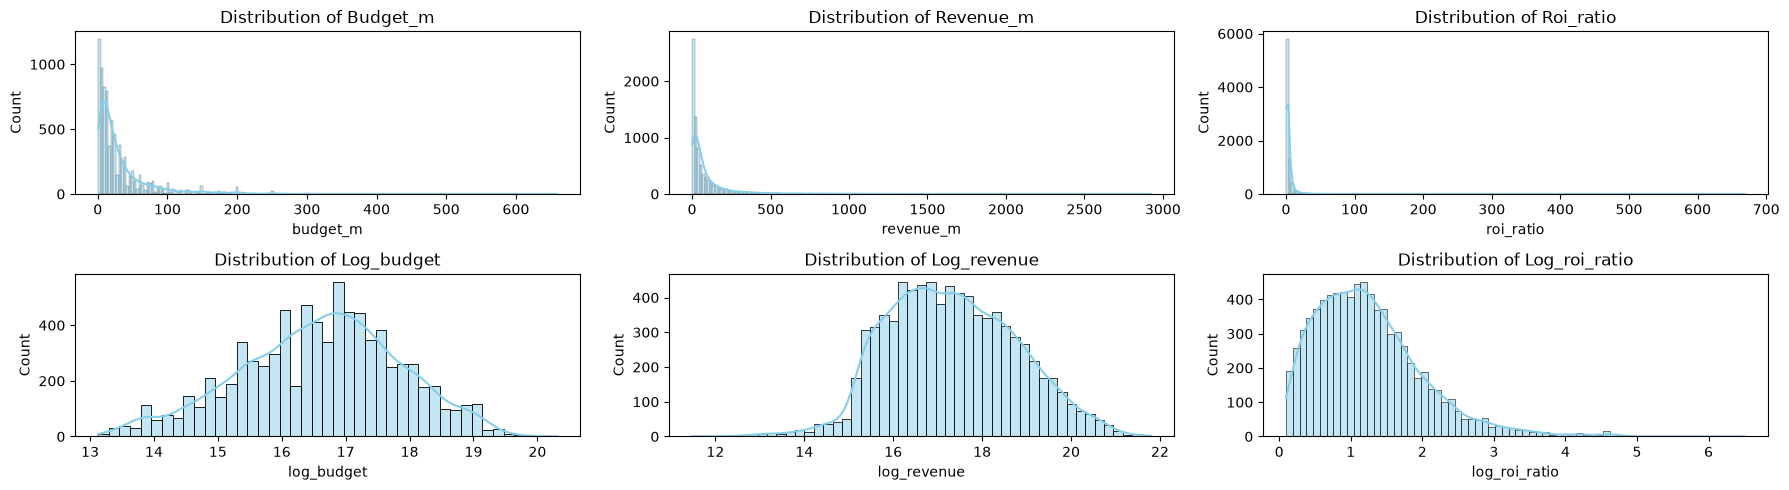

In [48]:
# 2. Distributions (Histograms + KDE)
fig, axes = plt.subplots(2, 3, figsize=(18, 5))
axes = axes.flatten()

for i, col in enumerate(dist_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribution of {col.capitalize()}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()


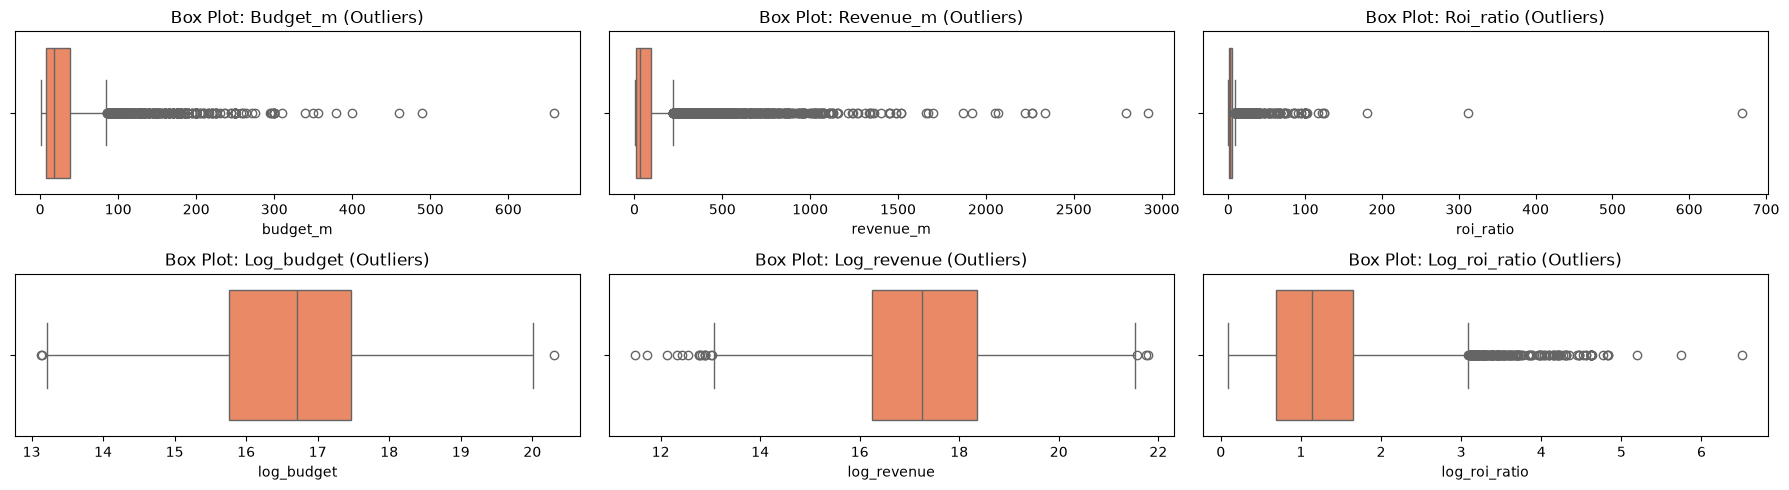

In [49]:
# 3. Outlier Detection (Box Plots)
fig, axes = plt.subplots(2, 3, figsize=(18, 5))
axes = axes.flatten()

for i, col in enumerate(dist_cols):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color="coral")
    axes[i].set_title(f"Box Plot: {col.capitalize()} (Outliers)")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

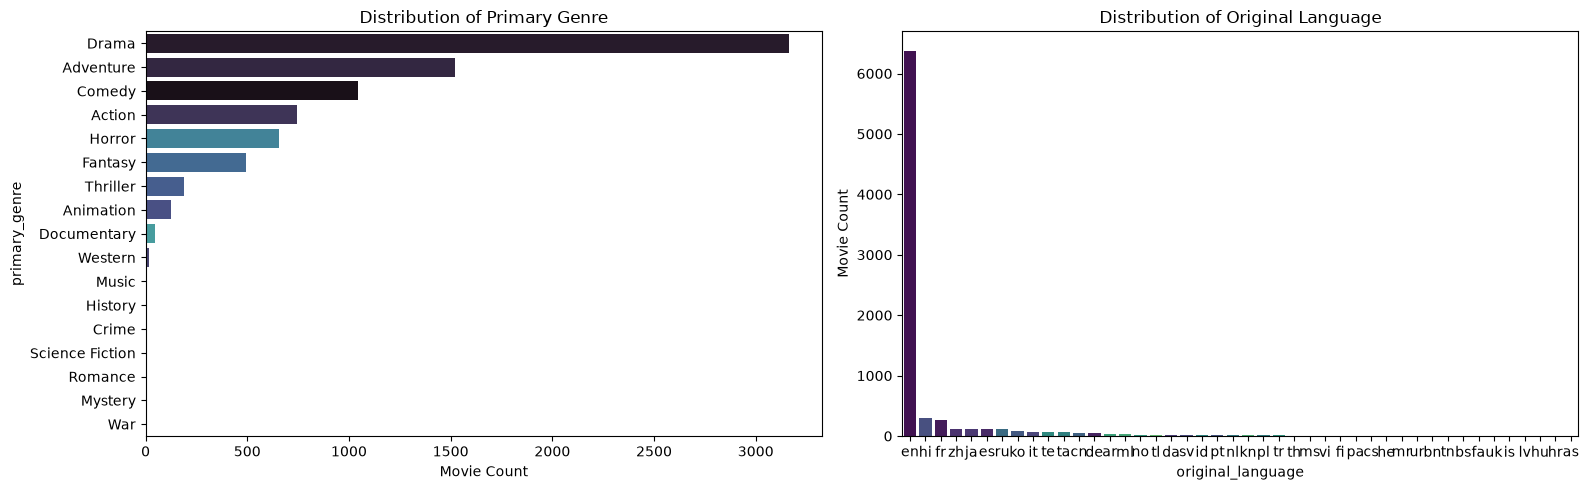

In [40]:
#Bar Charts for Categorical Frequency (Top Genres & Languages)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, y='primary_genre', order=df['primary_genre'].value_counts().index, palette='mako', ax=axes[0], hue='primary_genre', legend=False)
axes[0].set_title("Distribution of Primary Genre")
axes[0].set_xlabel("Movie Count")

sns.countplot(data=df, x='original_language', order=df['original_language'].value_counts().index, palette='viridis', ax=axes[1], hue='original_language', legend=False)
axes[1].set_title("Distribution of Original Language")
axes[1].set_ylabel("Movie Count")

plt.tight_layout()
plt.show()

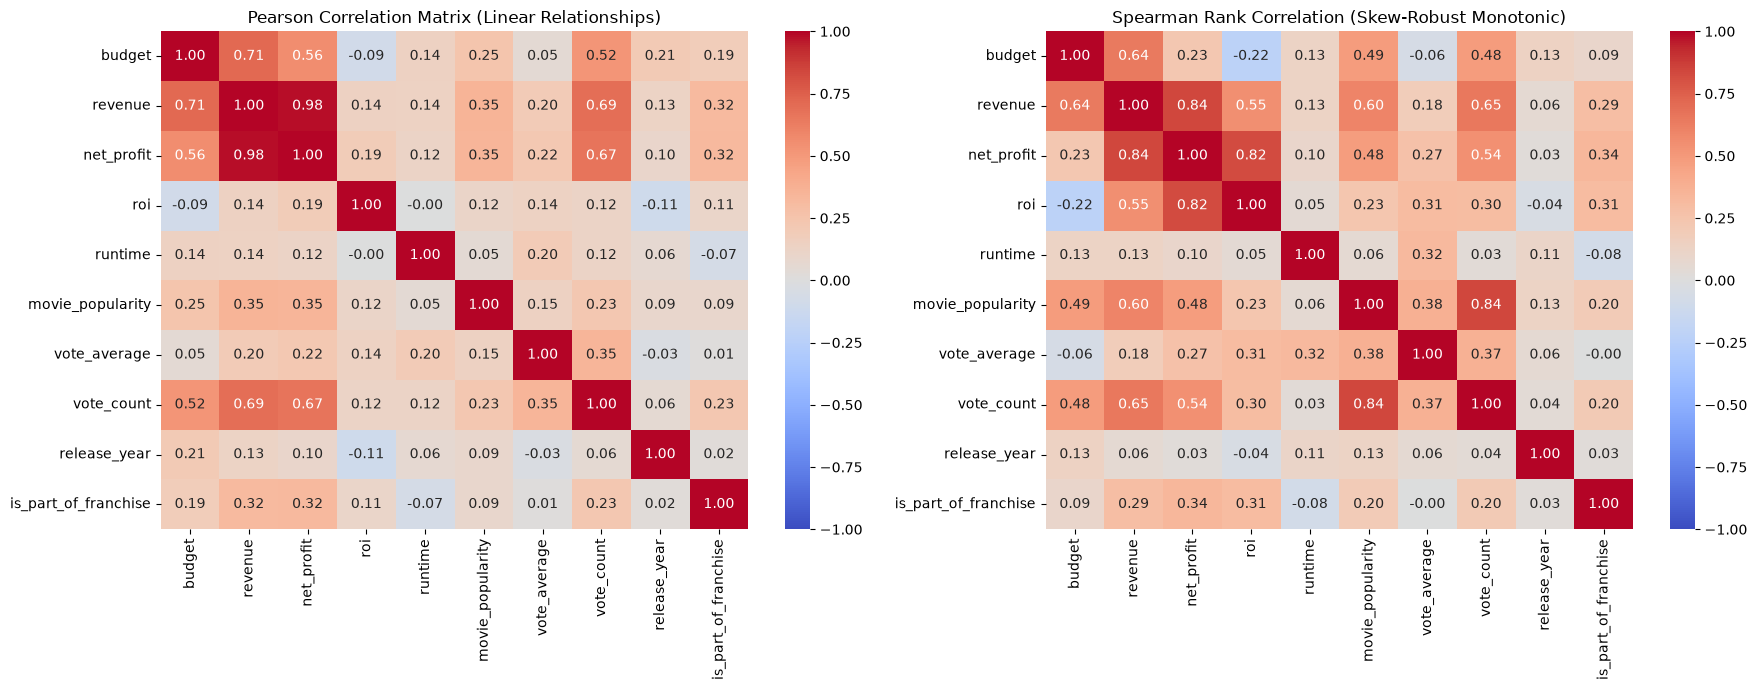

In [18]:
numeric_cols = [
    'budget', 'revenue', 'net_profit', 'roi', 
    'runtime', 'movie_popularity', 'vote_average', 'vote_count',
    'release_year', 'is_part_of_franchise'
]
numeric_df = df[numeric_cols]

# 2a. Heatmaps (Pearson for Linear vs. Spearman for Monotonic/Skewed Features)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(numeric_df.corr(method='pearson'), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Pearson Correlation Matrix (Linear Relationships)")

sns.heatmap(numeric_df.corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Spearman Rank Correlation (Skew-Robust Monotonic)")

plt.tight_layout()
plt.show()

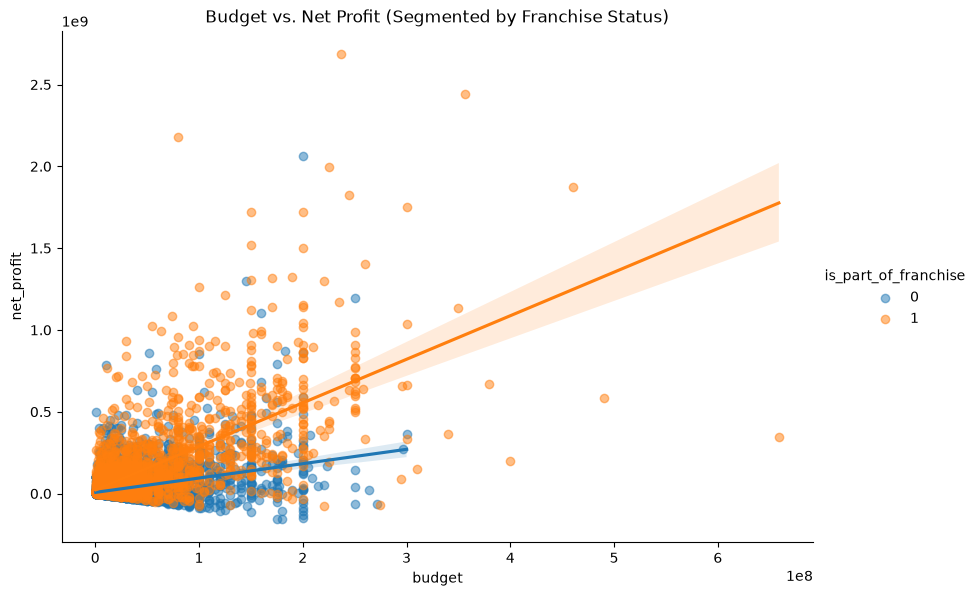

In [19]:
#Scatter Plots: Feature-to-Target Relationships
# Budget vs Net Profit broken down by Franchise status
sns.lmplot(
    data=df, x='budget', y='net_profit', hue='is_part_of_franchise',
    height=6, aspect=1.4, scatter_kws={'alpha': 0.5}
)
plt.title("Budget vs. Net Profit (Segmented by Franchise Status)")
plt.show()